In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/results.csv", keep_default_na=False)
print(df.shape)
print(df.head())

(39, 20)
  workload variant sweep_param  ...  window  worst_window_cycles  seed
0     ring           line_size  ...     100                 2575     1
1     ring           line_size  ...     100                 1387     1
2     ring           line_size  ...     100                  793     1
3   movavg           line_size  ...     100                 1684     1
4   movavg           line_size  ...     100                  892     1

[5 rows x 20 columns]


In [2]:
base = df[(df.ways == 4) & (df.line_size == 32)].copy()
base["name"] = (base.workload + " " + base.variant).str.strip()
print(base[["name", "accesses", "misses", "hit_rate", "total_cycles", "worst_window_cycles"]])

             name  accesses  ...  total_cycles  worst_window_cycles
1            ring      8192  ...         20864                 1387
4          movavg     65000  ...         65792                  892
7     structs aos      1000  ...        100000                10000
10    structs soa      1000  ...         13375                 1387
15  traversal row      4096  ...         54784                 1387
23  traversal col      4096  ...        409600                10000
31       conflict      4096  ...          4492                  496
37      coldstart      7680  ...         26688                 1387

[8 rows x 6 columns]


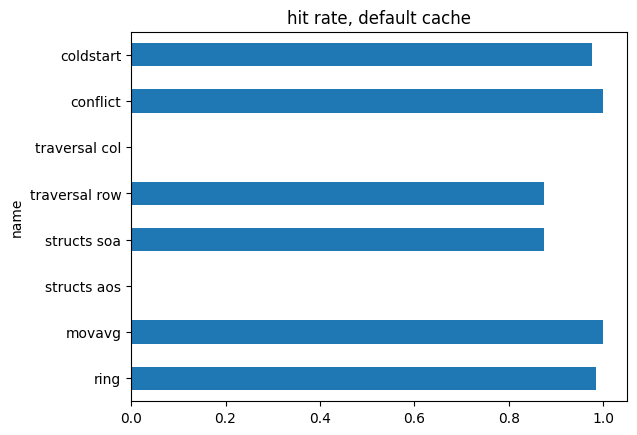

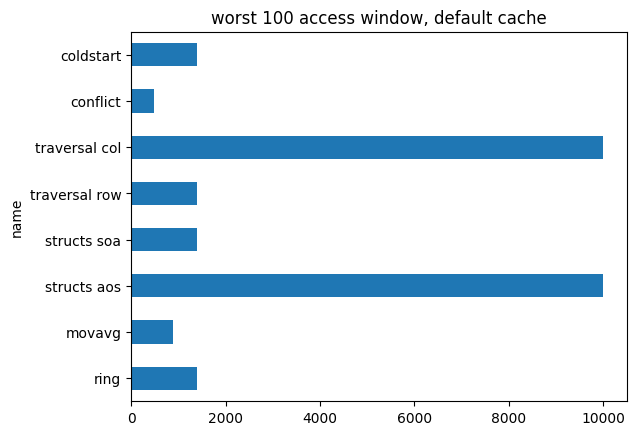

In [3]:
base.plot.barh(x="name", y="hit_rate", legend=False)
plt.title("hit rate, default cache")
plt.show()

base.plot.barh(x="name", y="worst_window_cycles", legend=False)
plt.title("worst 100 access window, default cache")
plt.show()

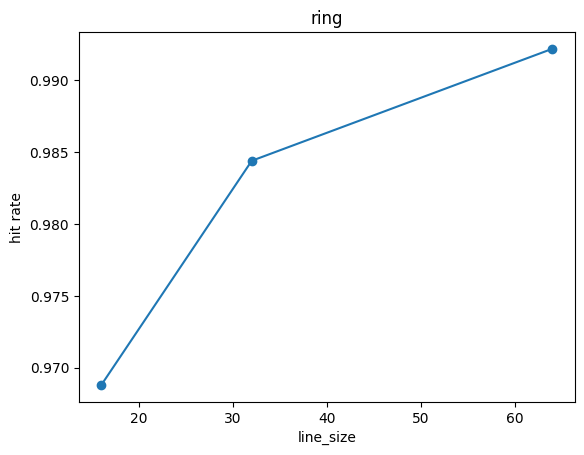

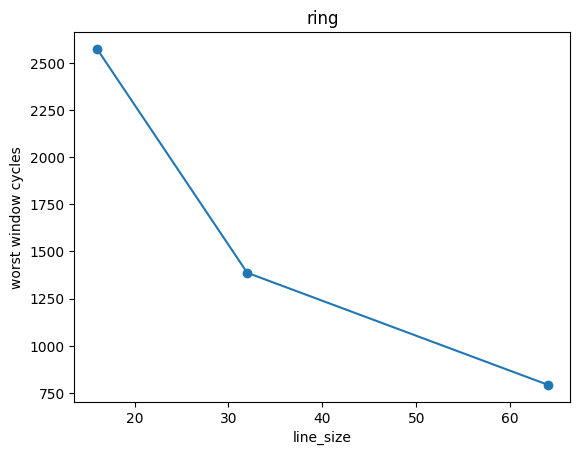

In [4]:
r = df[df.workload == "ring"]
plt.plot(r.sweep_value, r.hit_rate, marker="o")
plt.xlabel("line_size")
plt.ylabel("hit rate")
plt.title("ring")
plt.show()

plt.plot(r.sweep_value, r.worst_window_cycles, marker="o")
plt.xlabel("line_size")
plt.ylabel("worst window cycles")
plt.title("ring")
plt.show()

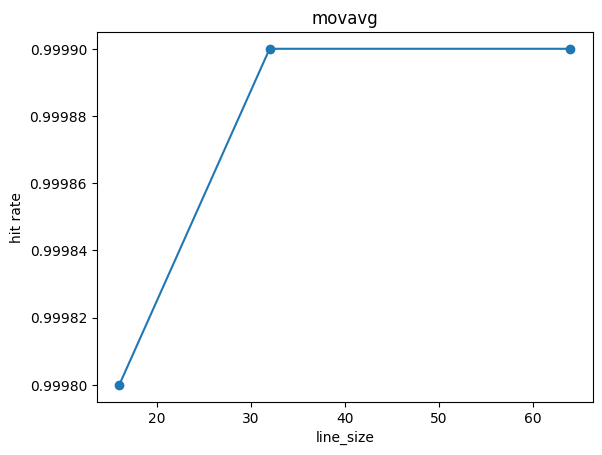

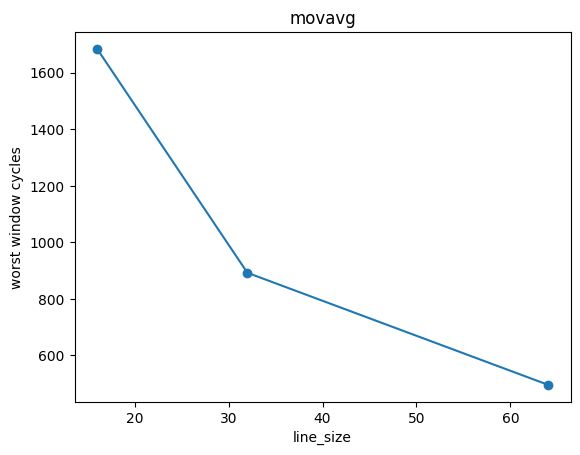

In [5]:
r = df[df.workload == "movavg"]
plt.plot(r.sweep_value, r.hit_rate, marker="o")
plt.xlabel("line_size")
plt.ylabel("hit rate")
plt.title("movavg")
plt.show()

plt.plot(r.sweep_value, r.worst_window_cycles, marker="o")
plt.xlabel("line_size")
plt.ylabel("worst window cycles")
plt.title("movavg")
plt.show()

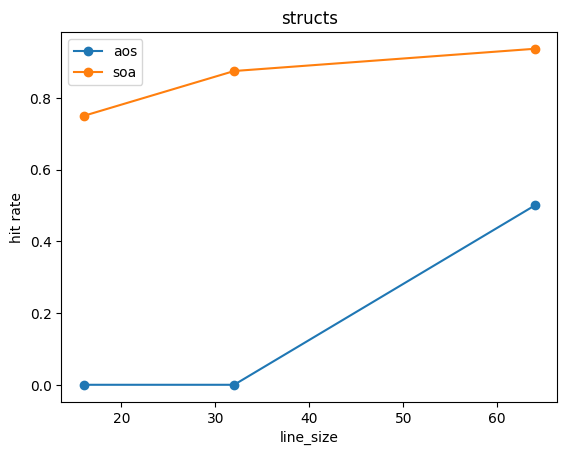

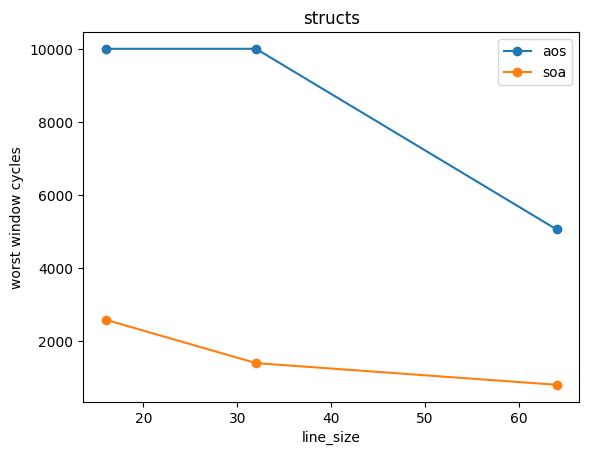

In [6]:
r = df[df.workload == "structs"]
for v in ['aos', 'soa']:
    x = r[r.variant == v]
    plt.plot(x.sweep_value, x.hit_rate, marker="o", label=v)
plt.xlabel("line_size")
plt.ylabel("hit rate")
plt.legend()
plt.title("structs")
plt.show()

for v in ['aos', 'soa']:
    x = r[r.variant == v]
    plt.plot(x.sweep_value, x.worst_window_cycles, marker="o", label=v)
plt.xlabel("line_size")
plt.ylabel("worst window cycles")
plt.legend()
plt.title("structs")
plt.show()

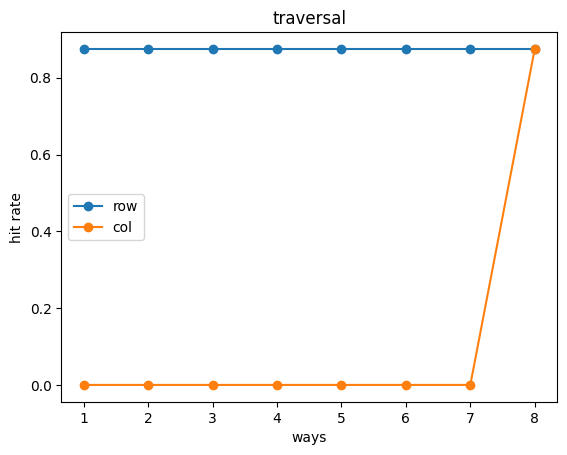

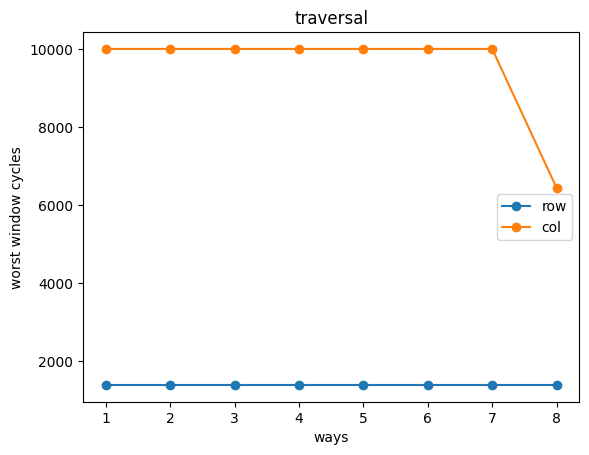

In [7]:
r = df[df.workload == "traversal"]
for v in ['row', 'col']:
    x = r[r.variant == v]
    plt.plot(x.sweep_value, x.hit_rate, marker="o", label=v)
plt.xlabel("ways")
plt.ylabel("hit rate")
plt.legend()
plt.title("traversal")
plt.show()

for v in ['row', 'col']:
    x = r[r.variant == v]
    plt.plot(x.sweep_value, x.worst_window_cycles, marker="o", label=v)
plt.xlabel("ways")
plt.ylabel("worst window cycles")
plt.legend()
plt.title("traversal")
plt.show()

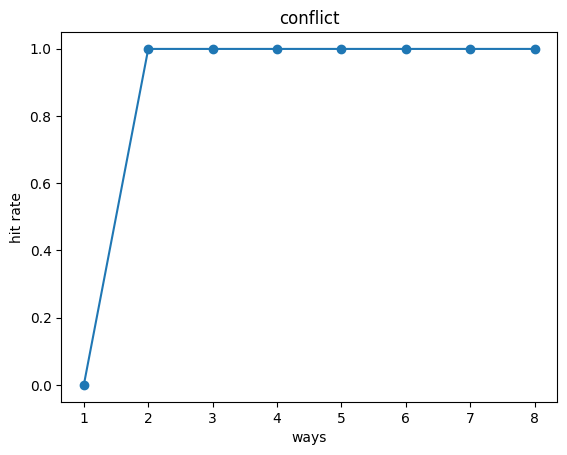

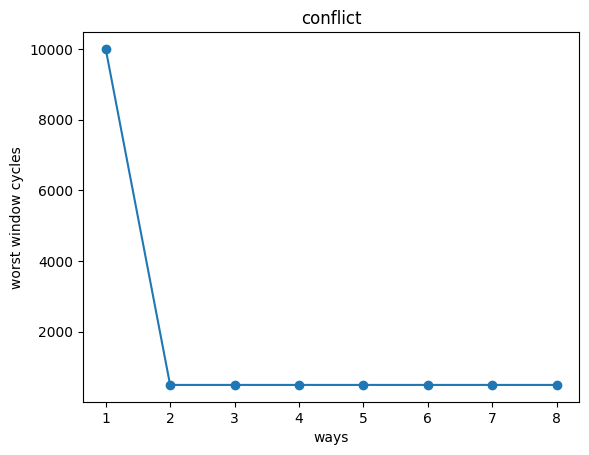

In [8]:
r = df[df.workload == "conflict"]
plt.plot(r.sweep_value, r.hit_rate, marker="o")
plt.xlabel("ways")
plt.ylabel("hit rate")
plt.title("conflict")
plt.show()

plt.plot(r.sweep_value, r.worst_window_cycles, marker="o")
plt.xlabel("ways")
plt.ylabel("worst window cycles")
plt.title("conflict")
plt.show()

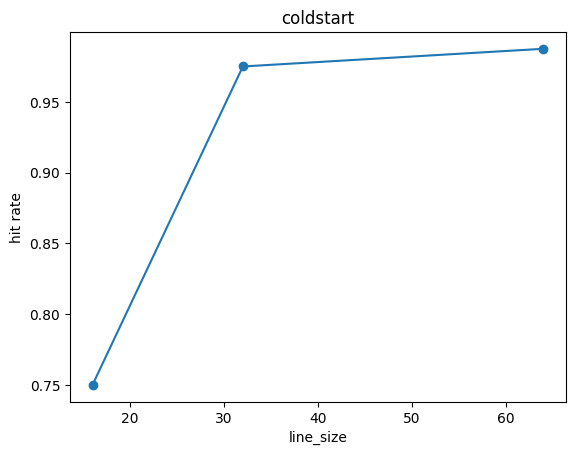

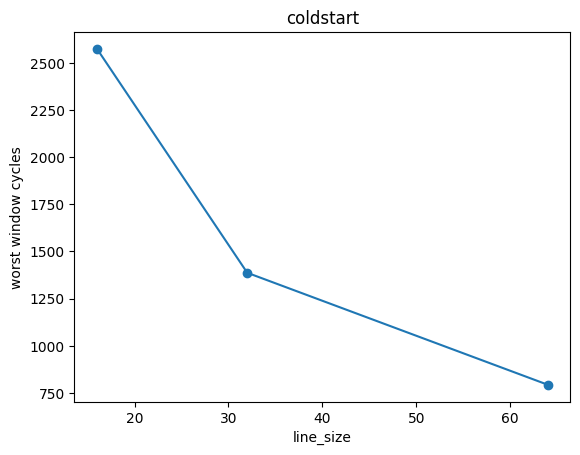

In [9]:
r = df[df.workload == "coldstart"]
plt.plot(r.sweep_value, r.hit_rate, marker="o")
plt.xlabel("line_size")
plt.ylabel("hit rate")
plt.title("coldstart")
plt.show()

plt.plot(r.sweep_value, r.worst_window_cycles, marker="o")
plt.xlabel("line_size")
plt.ylabel("worst window cycles")
plt.title("coldstart")
plt.show()

In [10]:
aos = base[(base.workload == "structs") & (base.variant == "aos")].misses.iloc[0]
soa = base[(base.workload == "structs") & (base.variant == "soa")].misses.iloc[0]
print("structs misses, aos vs soa:", aos, soa, aos / soa)

col = base[(base.workload == "traversal") & (base.variant == "col")].misses.iloc[0]
row = base[(base.workload == "traversal") & (base.variant == "row")].misses.iloc[0]
print("traversal misses, col vs row:", col, row, col / row)

c1 = df[(df.workload == "conflict") & (df.ways == 1)].misses.iloc[0]
c2 = df[(df.workload == "conflict") & (df.ways == 2)].misses.iloc[0]
print("conflict misses, 1 way vs 2 ways:", c1, c2)

cold = base[base.workload == "coldstart"].worst_window_cycles.iloc[0]
print("coldstart worst window:", cold, "(100 once warm)")

structs misses, aos vs soa: 1000 125 8.0
traversal misses, col vs row: 4096 512 8.0
conflict misses, 1 way vs 2 ways: 4096 4
coldstart worst window: 1387 (100 once warm)


In [11]:
base["worst_per_access"] = base.worst_window_cycles / base.window
base["ratio"] = base.worst_per_access / base.cost_mean
print(base[["name", "cost_mean", "worst_per_access", "ratio"]].round(2))

             name  cost_mean  worst_per_access  ratio
1            ring       2.55             13.87   5.45
4          movavg       1.01              8.92   8.81
7     structs aos     100.00            100.00   1.00
10    structs soa      13.38             13.87   1.04
15  traversal row      13.38             13.87   1.04
23  traversal col     100.00            100.00   1.00
31       conflict       1.10              4.96   4.52
37      coldstart       3.48             13.87   3.99
